# belief eye neural analysis


## imports

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:

import sys
import os
from pathlib import Path
import configparser
config = configparser.ConfigParser()
config.read_file(open('privateconfig'))
resdir = Path(config['Datafolder']['data'])
workdir = Path(config['Codefolder']['workspace'])
os.chdir(workdir)
# analysis
from scipy.io import loadmat
from sklearn.decomposition import FastICA
from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_regression
from sklearn.model_selection import KFold
from sklearn.linear_model import LassoCV, Lasso
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
from sklearn.cross_decomposition import CCA
# misc
import pickle
from collections import defaultdict
from neural_plot_ult import *
import time
tic=time.time()
import warnings
warnings.filterwarnings('ignore')

In [3]:
# run this once per notebook session  —  ideally in the first cell
from IPython import get_ipython

def notify_exc(shell, etype, evalue, tb, tb_offset=None):
    # 1. push notification
    summary = f"{etype.__name__}: {evalue}"
    notify(msg=summary, title="Python Error")

    # 2. let IPython show its normal traceback
    shell.showtraceback((etype, evalue, tb), tb_offset=tb_offset)
    return None            # ← must be None or a list of strings

get_ipython().set_custom_exc((Exception,), notify_exc)


## load data

## load standard data


In [4]:
df = pd.read_pickle(resdir/'0417_m51df.pkl')
len(df)
df=df[df.session==41]

In [5]:
def process_one(y):
    related_taskvar=np.array(normalize_z(y))
    mask=(related_taskvar > -4) & (related_taskvar < 4)
    related_taskvar[~mask]=0
    return related_taskvar, mask

def process(rawtaskvar, returnmask=False):
    # normalize each item to 0 mean 1 std
    rawtaskvar=[np.array(normalize_z(y)) for y in rawtaskvar]
    related_taskvar=np.vstack(rawtaskvar).T
    # related_taskvar=np.clip(related_taskvar,-4,4)
    mask=(related_taskvar > -4) & (related_taskvar < 4)
    mask=np.all(mask, axis=1)
    related_taskvar=related_taskvar[mask]
    if returnmask:
        return related_taskvar, mask
    return related_taskvar
def process_list(rawtaskvar, returnmask=False):
    # normalize each item to 0 mean 1 std
    rawtaskvar=[np.array(normalize_z(y)) for y in rawtaskvar]
    mask=[(a > -4) & (a < 4) for a in rawtaskvar]
    mask=np.all(mask)
    related_taskvar=[a[mask] for a in rawtaskvar]
    if returnmask:
        return related_taskvar, mask
    return related_taskvar

In [6]:
# error distribution
def get_stop_error(row):
    return ((row.fx[-1]-row.mx[-1])**2+(row.fy[-1]-row.my[-1])**2)**0.5
df['state_error']=df.apply(get_stop_error, axis=1)
def get_stop_error(row):
    return ((row.fx[-1]-row.bmx[-1])**2+(row.fy[-1]-row.bmy[-1])**2)**0.5
df['belief_error']=df.apply(get_stop_error, axis=1)

# time ratio
df['time_ratio']=df.apply(lambda x: x.timer/x.timer[-1], axis=1)


In [7]:
for session in sorted(df.session.unique())[:1]:
    sessdf=df[(df.session==session)]

state=np.concatenate(sessdf.belief_ff_hori.to_numpy())
belief=np.concatenate(sessdf.ff_hori.to_numpy())
eye=np.concatenate(sessdf.eye_hori.to_numpy())
timeratio=np.concatenate(sessdf.time_ratio.to_numpy())
timer=np.concatenate(sessdf.timer.to_numpy())
countdown=np.concatenate(sessdf.countdown.to_numpy())


In [8]:
# make a df by time (each row is a time, instead of a trial)
sessdf['density_t']=sessdf.apply(lambda x: np.array([[x.density]*len(x.mx)]).reshape(-1), axis=1)
sessdf['fullon_t']=sessdf.apply(lambda x: np.array([[x.fullon]*len(x.mx)]).reshape(-1), axis=1)
sessdf['error_t']=sessdf.apply(lambda x: np.array([[x.error]*len(x.mx)]).reshape(-1), axis=1)

timedf=pd.DataFrame({'timer':timer})
timedf['rawcov']=list(np.vstack(sessdf['rawcov'].to_numpy()))
timedf['belief']=np.concatenate(sessdf.belief_ff_hori.to_numpy())
timedf['state']=np.concatenate(sessdf.ff_hori.to_numpy())
timedf['eye']=np.concatenate(sessdf.eye_hori.to_numpy())
timedf['timeratio']=np.concatenate(sessdf.time_ratio.to_numpy())
timedf['mv']=np.concatenate(sessdf.mv.to_numpy())
timedf['mw']=np.concatenate(sessdf.mw.to_numpy())
timedf['belief_heading']=np.concatenate(sessdf.belief_heading.to_numpy())
timedf['timer']=np.concatenate(sessdf.timer.to_numpy())
timedf['countdown']=np.concatenate(sessdf.countdown.to_numpy())
timedf['belief_angle_from_start']=np.concatenate(sessdf.belief_angle_from_start.to_numpy())
timedf['PPC']=list(np.vstack(sessdf.PPC.to_numpy()))

timedf['uncertainty']=list(np.concatenate(sessdf.relcov.to_numpy()))

timedf['density']=np.concatenate(sessdf.density_t.to_numpy())
timedf['fullon']=np.concatenate(sessdf.fullon_t.to_numpy())
timedf['error']=np.concatenate(sessdf.error_t.to_numpy())


timedf['dbelief']=np.concatenate(sessdf.apply(lambda x: np.diff(x.belief_ff_hori, prepend=x.belief_ff_hori[:1],axis=0),axis=1).to_numpy())
timedf['deye']=np.concatenate(sessdf.apply(lambda x: np.diff(x.eye_hori, prepend=x.eye_hori[:1],axis=0),axis=1).to_numpy())
timedf['dneural']=list(np.vstack(sessdf.apply(lambda x: np.diff(x.PPC, prepend=x.PPC[:1], axis=0),axis=1).to_numpy()))


timedf.head()
timedf = timedf.dropna(subset=['eye', 'state', 'belief'])

## load iti data

In [10]:
itidf = pd.read_pickle(resdir/'0421iti_m51df.pkl')
len(itidf)
itidf=itidf[itidf.session==41]
itidf['time_ratio']=itidf.apply(lambda x: x.timer/x.timer[-1], axis=1)

In [11]:
for session in sorted(itidf.session.unique())[:1]:
    sessitidf=itidf[(itidf.session==session)]

# state=np.concatenate(sessitidf.belief_ff_hori.to_numpy())
belief=np.concatenate(sessitidf.ff_hori.to_numpy())
eye=np.concatenate(sessitidf.eye_hori.to_numpy())
timeratio=np.concatenate(sessitidf.time_ratio.to_numpy())
timer=np.concatenate(sessitidf.timer.to_numpy())
countdown=np.concatenate(sessitidf.countdown.to_numpy())

# make a itidf by time (each row is a time, instead of a trial)
sessitidf['density_t']=sessitidf.apply(lambda x: np.array([[x.density]*len(x.mx)]).reshape(-1), axis=1)
sessitidf['fullon_t']=sessitidf.apply(lambda x: np.array([[x.fullon]*len(x.mx)]).reshape(-1), axis=1)
sessitidf['error_t']=sessitidf.apply(lambda x: np.array([[x.error]*len(x.mx)]).reshape(-1), axis=1)

timeitidf=pd.DataFrame({'timer':timer})
# timeitidf['rawcov']=list(np.vstack(sessitidf['rawcov'].to_numpy()))
# timeitidf['belief']=np.concatenate(sessitidf.belief_ff_hori.to_numpy())
timeitidf['state']=np.concatenate(sessitidf.ff_hori.to_numpy())
timeitidf['eye']=np.concatenate(sessitidf.eye_hori.to_numpy())
timeitidf['timeratio']=np.concatenate(sessitidf.time_ratio.to_numpy())
timeitidf['mv']=np.concatenate(sessitidf.mv.to_numpy())
timeitidf['mw']=np.concatenate(sessitidf.mw.to_numpy())
# timeitidf['belief_heading']=np.concatenate(sessitidf.belief_heading.to_numpy())
timeitidf['timer']=np.concatenate(sessitidf.timer.to_numpy())
timeitidf['countdown']=np.concatenate(sessitidf.countdown.to_numpy())
# timeitidf['belief_angle_from_start']=np.concatenate(sessitidf.belief_angle_from_start.to_numpy())
timeitidf['PPC']=list(np.vstack(sessitidf.PPC.to_numpy()))

# timeitidf['uncertainty']=list(np.concatenate(sessitidf.relcov.to_numpy()))

timeitidf['density']=np.concatenate(sessitidf.density_t.to_numpy())
timeitidf['fullon']=np.concatenate(sessitidf.fullon_t.to_numpy())
timeitidf['error']=np.concatenate(sessitidf.error_t.to_numpy())


# timeitidf['dbelief']=np.concatenate(sessitidf.apply(lambda x: np.diff(x.belief_ff_hori, prepend=x.belief_ff_hori[:1],axis=0),axis=1).to_numpy())
timeitidf['deye']=np.concatenate(sessitidf.apply(lambda x: np.diff(x.eye_hori, prepend=x.eye_hori[:1],axis=0),axis=1).to_numpy())
timeitidf['dneural']=list(np.vstack(sessitidf.apply(lambda x: np.diff(x.PPC, prepend=x.PPC[:1], axis=0),axis=1).to_numpy()))


timeitidf.head()
# timeitidf = timeitidf.dropna(subset=['eye', 'state'])

,timer,state,eye,timeratio,mv,mw,countdown,PPC,density,fullon,error,deye,dneural
0,0,-0.411339,28.940651,0.000000,-0.003190,-0.001378,-37,"[0.106192164, 0.19640955, 0.0, 0.0, 0.05650172...",0.005,0,174.501175,0.000000,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1,1,-0.470667,28.920336,0.027027,0.023303,0.007235,-36,"[0.10775572, 0.1846899, 0.0, 3.3458742e-05, 0....",0.005,0,174.501175,-0.020315,"[0.0015635565, -0.011719659, 0.0, 3.3458742e-0..."
2,2,-0.533338,28.902283,0.054054,-0.004524,-0.002155,-35,"[0.109807715, 0.16330647, 0.0, 8.815204e-05, 0...",0.005,0,174.501175,-0.018053,"[0.0020519942, -0.02138342, 0.0, 5.4693297e-05..."
3,3,-0.500699,28.880598,0.081081,-0.015537,-0.000820,-34,"[0.110675946, 0.13578184, 0.0, 0.0002181784, 0...",0.005,0,174.501175,-0.021685,"[0.00086823106, -0.027524635, 0.0, 0.000130026..."
4,4,-0.481149,28.881540,0.108108,0.015418,0.008251,-33,"[0.10878229, 0.10615871, 0.0, 0.00050727994, 0...",0.005,0,174.501175,0.000942,"[-0.0018936545, -0.029623128, 0.0, 0.000289101..."


# done

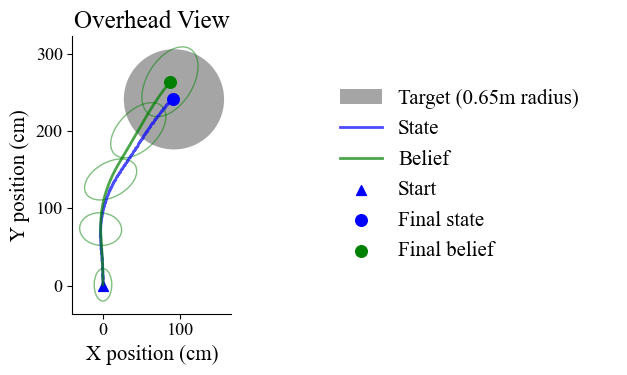

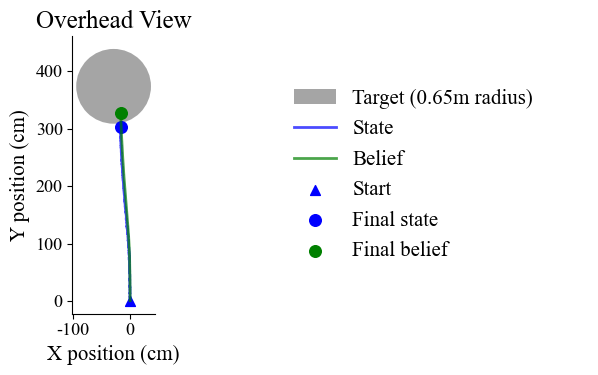

In [75]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Ellipse, Circle
import pandas as pd

def plot_navigation_views(sessdf):
    """
    Plot navigation task views:
    - Left: Overhead view with target circles and belief uncertainty ellipses
    - Right: Screen view showing horizontal and vertical components
    
    Args:
        sessdf: DataFrame with session data
    """
    # Create figure with 2 subplots
    fig, axes = plt.subplots(1, 2, figsize=(7, 4))

    ax = axes[0]

    # Sample a few trials for clarity (adjust as needed)
    sample_size = min(1, len(sessdf))
    sample_trials = sessdf.sample(sample_size)
    
    for idx, trial in sample_trials.iterrows():
        # Plot the target with 0.65m radius
        target_circle = Circle((trial.fx[-1], trial.fy[-1]), 65, fill=True, facecolor='grey',
                              edgecolor='None', linestyle='--', alpha=0.7, 
                              label='Target (0.65m radius)' if idx == sample_trials.index[0] else "")
        ax.add_patch(target_circle)
        
        # Plot the true trajectory (state)
        ax.plot(trial.mx, trial.my, 'b-', alpha=0.7, label='State' if idx == sample_trials.index[0] else "")
        
        # Plot the belief trajectory
        ax.plot(trial.bmx, trial.bmy, 'g-', alpha=0.7, label='Belief' if idx == sample_trials.index[0] else "")
        
        # Plot belief uncertainty as ellipses at intervals
        num_points = len(trial.bmx)
        # Plot ellipses at a few points along the trajectory
        indices = np.linspace(0, num_points-1, min(5, num_points)).astype(int)
        
        for i in indices:
            # Extract the covariance matrix at this point
            cov_matrix = trial.relcov[i]*9 # 3std
            
            # Calculate eigenvalues and eigenvectors for the ellipse
            if cov_matrix.shape == (2, 2):
                eigvals, eigvecs = np.linalg.eigh(cov_matrix)
                
                # The ellipse size is determined by the eigenvalues
                # Scale the ellipse to represent 95% confidence interval (2 standard deviations)
                scale = 2
                width, height = 2 * scale * np.sqrt(eigvals)
                
                # The rotation angle in degrees
                angle = np.degrees(np.arctan2(eigvecs[1, 0], eigvecs[0, 0]))
                
                # Create and add the ellipse
                ellipse = Ellipse((trial.bmx[i], trial.bmy[i]), width, height, 
                                 angle=angle, fill=False, edgecolor='green', alpha=0.5)
                ax.add_patch(ellipse)
    
    # Mark the starting positions
    for idx, trial in sample_trials.iterrows():
        ax.scatter(trial.mx[0], trial.my[0], c='blue', s=50, 
                  marker='^', label='Start' if idx == sample_trials.index[0] else "")
    
    # Mark the final positions
    for idx, trial in sample_trials.iterrows():
        ax.scatter(trial.mx[-1], trial.my[-1], c='blue', s=70, 
                  marker='o', label='Final state' if idx == sample_trials.index[0] else "")
        ax.scatter(trial.bmx[-1], trial.bmy[-1], c='green', s=70, 
                  marker='o', label='Final belief' if idx == sample_trials.index[0] else "")
        # ax.scatter(trial.fx[-1], trial.fy[-1], c='red', s=70, 
        #           marker='X', label='Target' if idx == sample_trials.index[0] else "")
    
    ax.set_xlabel('X position (cm)')
    ax.set_ylabel('Y position (cm)')
    ax.set_title('Overhead View')
    
    # ax.grid(True)
    ax.set_aspect('equal')
    


    handles, labels = ax.get_legend_handles_labels()
    ax = axes[1]
    ax.axis('off')
    ax.legend(handles, labels, loc='center', frameon=False)
    plt.tight_layout()
    plt.show()

# Call the function to generate the plots
plot_navigation_views(sessdf[sessdf.fullon==False])
plot_navigation_views( sessdf[sessdf.fullon==True])

# plots